# Mini Project 01 — Titanic Classification
## Section B — From-Scratch Implementations (NumPy only)

**Deliverable:** `B_from_scratch_models.ipynb`

All models, metrics, cross-validation and tuning code below are written with **NumPy only** — no `sklearn` models or metrics. (`matplotlib` is used purely to draw figures, and `json`/`os`/`time` for housekeeping.)

| Family | Models implemented |
|---|---|
| Logistic regression | Standard (no regularisation) · **L1** (proximal gradient / soft-thresholding) · **L2** (ridge) |
| Ensembles | **Bagging** with configurable number of estimators and tree depth ("levels") · **AdaBoost** with decision stumps |
| API | `fit(X, y)` · `predict_proba(X)` · `predict(X, threshold=0.5)` |
| Metrics (≥ 4) | confusion matrix, accuracy, precision, recall, F1, specificity, balanced accuracy, MCC, log-loss, ROC curve + AUC, Precision–Recall curve + AP |

**Conventions.** `predict_proba(X)` returns a 1-D array with the probability of class 1 (survived). Hyper-parameters are chosen by **cross-validation on the training set only**; the test set is touched once, for the final evaluation.

In [1]:
import os, time, json, platform
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

SEED = 42                                   # global seed — identical in every notebook
np.random.seed(SEED)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
os.makedirs("figs", exist_ok=True); os.makedirs("data/results", exist_ok=True)
print("Python", platform.python_version(), "| numpy", np.__version__, "| matplotlib", matplotlib.__version__)

NB_START = time.perf_counter()

Python 3.12.3 | numpy 2.4.4 | matplotlib 3.10.8


## 1. Load the identical train/test split produced in Section A

In [2]:
d = np.load("data/processed/titanic_split.npz")
X_train, X_test, y_train, y_test = d["X_train"], d["X_test"], d["y_train"], d["y_test"]
feature_names = [str(f) for f in d["feature_names"]]
print("X_train", X_train.shape, "X_test", X_test.shape, "| positives: train %.3f  test %.3f" % (y_train.mean(), y_test.mean()))
print("features:", feature_names)

X_train (712, 9) X_test (179, 9) | positives: train 0.383  test 0.385
features: ['Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Pclass_2', 'Pclass_3', 'Embarked_Q', 'Embarked_S']


## 2. Evaluation toolkit (from scratch)
* **Confusion matrix** `[[TN, FP], [FN, TP]]`
* **Accuracy, precision, recall (sensitivity), specificity, F1, balanced accuracy, Matthews correlation coefficient**
* **Log-loss** (clipped for numerical safety)
* **ROC curve** (sort by score, cumulative TP/FP at each distinct threshold) and **AUC** by the trapezoid rule
* **Precision–Recall curve** and **Average Precision** $AP=\sum_n (R_n-R_{n-1})P_n$

In [3]:
def confusion_matrix(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    tn = int(np.sum((y_true == 0) & (y_pred == 0))); fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0))); tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    return np.array([[tn, fp], [fn, tp]])

def _div(a, b):
    return a / b if b > 0 else 0.0

def log_loss(y_true, p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return float(-np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p)))

def roc_curve(y_true, y_score):
    order = np.argsort(-y_score, kind="mergesort")
    y, s = y_true[order], y_score[order]
    tps, fps = np.cumsum(y), np.cumsum(1 - y)
    last = np.r_[np.where(np.diff(s))[0], y.size - 1]          # last index of each distinct score
    tpr = np.r_[0.0, tps[last] / tps[-1]]
    fpr = np.r_[0.0, fps[last] / fps[-1]]
    return fpr, tpr

def auc_trapezoid(x, y):
    return float(np.sum(np.diff(x) * (y[1:] + y[:-1]) / 2.0))

def roc_auc_score(y_true, y_score):
    fpr, tpr = roc_curve(y_true, y_score); return auc_trapezoid(fpr, tpr)

def pr_curve(y_true, y_score):
    order = np.argsort(-y_score, kind="mergesort")
    y, s = y_true[order], y_score[order]
    tps, fps = np.cumsum(y), np.cumsum(1 - y)
    last = np.r_[np.where(np.diff(s))[0], y.size - 1]
    precision = tps[last] / (tps[last] + fps[last]); recall = tps[last] / tps[-1]
    return np.r_[1.0, precision], np.r_[0.0, recall]

def average_precision(y_true, y_score):
    p, r = pr_curve(y_true, y_score)
    return float(np.sum(np.diff(r) * p[1:]))

def classification_metrics(y_true, y_pred, y_prob):
    (tn, fp), (fn, tp) = confusion_matrix(y_true, y_pred)
    prec, rec, spec = _div(tp, tp + fp), _div(tp, tp + fn), _div(tn, tn + fp)
    mcc_den = np.sqrt(float(tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    return {
        "accuracy":  (tp + tn) / (tp + tn + fp + fn),
        "precision": prec, "recall": rec, "specificity": spec,
        "f1": _div(2 * prec * rec, prec + rec),
        "balanced_accuracy": (rec + spec) / 2,
        "mcc": float((tp * tn - fp * fn) / mcc_den) if mcc_den > 0 else 0.0,
        "roc_auc": roc_auc_score(y_true, y_prob),
        "avg_precision": average_precision(y_true, y_prob),
        "log_loss": log_loss(y_true, y_prob),
    }

# --- tiny unit tests with hand-computed answers -------------------------------------------------
yt = np.array([0, 0, 1, 1]); ys = np.array([0.1, 0.4, 0.35, 0.8])      # classic textbook example
assert abs(roc_auc_score(yt, ys) - 0.75) < 1e-12
assert abs(average_precision(yt, ys) - 0.8333333333) < 1e-9
assert confusion_matrix(np.array([1, 0, 1, 0]), np.array([1, 1, 0, 0])).tolist() == [[1, 1], [1, 1]]
print("metric unit tests passed")

metric unit tests passed


## 3. Cross-validation helpers (from scratch)
Stratified K-fold built with NumPy only. Used to tune hyper-parameters on the **training set**.

In [4]:
def stratified_kfold_indices(y, k=5, seed=SEED):
    rng = np.random.default_rng(seed)
    folds = [[] for _ in range(k)]
    for cls in np.unique(y):
        idx = rng.permutation(np.where(y == cls)[0])
        for i, chunk in enumerate(np.array_split(idx, k)):
            folds[i].extend(chunk.tolist())
    return [np.array(sorted(f)) for f in folds]

def cv_score(make_model, X, y, k=5, seed=SEED, score="roc_auc"):
    folds, scores = stratified_kfold_indices(y, k, seed), []
    for i in range(k):
        va = folds[i]; tr = np.concatenate([folds[j] for j in range(k) if j != i])
        m = make_model().fit(X[tr], y[tr]); p = m.predict_proba(X[va])
        scores.append(roc_auc_score(y[va], p) if score == "roc_auc" else float(np.mean((p >= 0.5) == y[va])))
    return float(np.mean(scores)), float(np.std(scores))

f = stratified_kfold_indices(y_train, 5)
print("fold sizes:", [len(a) for a in f], "| positive rate per fold:", [round(float(y_train[a].mean()), 3) for a in f])

fold sizes: [143, 143, 143, 142, 141] | positive rate per fold: [0.385, 0.385, 0.385, 0.38, 0.383]


## 4. Logistic regression — standard, L1 and L2 (one class, three behaviours)

**Model.** $p(y=1\mid x)=\sigma(w^\top x+b)$, $\sigma(z)=1/(1+e^{-z})$.

**Objective** (mean log-loss + penalty; the bias $b$ is *never* penalised):

$$J(w,b)=\frac1n\sum_i\Big[\log(1+e^{z_i})-y_iz_i\Big]+\underbrace{\tfrac{\lambda}{2}\lVert w\rVert_2^2}_{\text{L2}}\;\text{ or }\;\underbrace{\lambda\lVert w\rVert_1}_{\text{L1}},\qquad z_i=w^\top x_i+b$$

**Gradient.** $\nabla_w=\frac1n X^\top(p-y)\,[+\lambda w\ \text{for L2}]$, $\;\nabla_b=\frac1n\sum_i(p_i-y_i)$.

**Optimiser.** Full-batch gradient descent with the safe step size $1/L$, where $L=\tfrac14\lambda_{\max}\big(\tfrac1n\tilde X^\top\tilde X\big)\,[+\lambda]$ is the Lipschitz constant of the gradient ($\tilde X=[X\;1]$). The non-differentiable **L1** penalty is handled with a **proximal gradient (ISTA)** step: after each gradient step, apply soft-thresholding $w\leftarrow\mathrm{sign}(w)\max(|w|-\eta\lambda,0)$, which produces *exact* zeros (true sparsity).

**Mapping to scikit-learn's `C`** (used in Section C): $C=\dfrac{1}{n\lambda}$ for both penalties.

In [5]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

class LogisticRegressionScratch:
    """Binary logistic regression trained with (proximal) gradient descent.

    penalty : None | 'l2' | 'l1'      lam : regularisation strength (lambda)
    """
    def __init__(self, penalty=None, lam=0.0, max_iter=20000, tol=1e-9):
        assert penalty in (None, "l1", "l2")
        self.penalty, self.lam, self.max_iter, self.tol = penalty, (0.0 if penalty is None else lam), max_iter, tol

    def _objective(self, X, y, w, b):
        z = X @ w + b
        loss = np.mean(np.logaddexp(0.0, z) - y * z)                     # stable log(1+e^z) - y z
        if self.penalty == "l2": loss += 0.5 * self.lam * np.sum(w ** 2)
        if self.penalty == "l1": loss += self.lam * np.sum(np.abs(w))
        return loss

    def _gradient(self, X, y, w, b):
        r = sigmoid(X @ w + b) - y
        gw = X.T @ r / len(y); gb = r.mean()
        if self.penalty == "l2": gw = gw + self.lam * w
        return gw, gb

    def fit(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y, float)
        n, p = X.shape
        Xa = np.c_[X, np.ones(n)]
        L = 0.25 * np.linalg.eigvalsh(Xa.T @ Xa / n).max() + (self.lam if self.penalty == "l2" else 0.0)
        eta = 1.0 / L                                                     # safe constant step size
        w, b = np.zeros(p), 0.0
        self.loss_history_ = [self._objective(X, y, w, b)]
        for it in range(self.max_iter):
            gw, gb = self._gradient(X, y, w, b)
            w_new, b_new = w - eta * gw, b - eta * gb
            if self.penalty == "l1":                                      # proximal (soft-threshold) step
                w_new = np.sign(w_new) * np.maximum(np.abs(w_new) - eta * self.lam, 0.0)
            delta = max(np.max(np.abs(w_new - w)), abs(b_new - b))
            w, b = w_new, b_new
            if it % 50 == 0: self.loss_history_.append(self._objective(X, y, w, b))
            if delta < self.tol: break
        self.coef_, self.intercept_, self.n_iter_ = w, b, it + 1
        return self

    def predict_proba(self, X):
        return sigmoid(np.asarray(X, float) @ self.coef_ + self.intercept_)   # P(y = 1)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

### 4.1 Mathematical verification — analytic gradient vs. numerical gradient
A central-difference check of the analytic gradient (smooth objectives: none and L2). The L1 penalty is verified separately by checking that the proximal operator yields exact zeros and that the objective decreases monotonically.

In [6]:
rng = np.random.default_rng(SEED)
Xg, yg = X_train[:200], y_train[:200].astype(float)
wg, bg = rng.normal(size=Xg.shape[1]) * 0.3, 0.1

for pen, lam in [(None, 0.0), ("l2", 0.1)]:
    m = LogisticRegressionScratch(penalty=pen, lam=lam)
    gw, gb = m._gradient(Xg, yg, wg, bg)
    num_w = np.zeros_like(wg); h = 1e-6
    for j in range(len(wg)):
        e = np.zeros_like(wg); e[j] = h
        num_w[j] = (m._objective(Xg, yg, wg + e, bg) - m._objective(Xg, yg, wg - e, bg)) / (2 * h)
    num_b = (m._objective(Xg, yg, wg, bg + h) - m._objective(Xg, yg, wg, bg - h)) / (2 * h)
    err = max(np.max(np.abs(gw - num_w)), abs(gb - num_b))
    print(f"penalty={str(pen):5s}  max |analytic - numeric| = {err:.2e}")
    assert err < 1e-7

# objective must decrease monotonically under the 1/L step size (all three variants)
for pen, lam in [(None, 0.0), ("l2", 0.05), ("l1", 0.02)]:
    m = LogisticRegressionScratch(penalty=pen, lam=lam).fit(X_train, y_train)
    h = np.array(m.loss_history_)
    assert np.all(np.diff(h) <= 1e-12), "objective increased!"
    print(f"{str(pen):5s}: objective {h[0]:.4f} -> {h[-1]:.4f}  (monotone, {m.n_iter_} iterations)")
m1 = LogisticRegressionScratch("l1", 0.05).fit(X_train, y_train)
print("L1 (lambda=0.05) exact zero coefficients:", int(np.sum(m1.coef_ == 0)), "of", len(m1.coef_))

penalty=None   max |analytic - numeric| = 1.03e-10
penalty=l2     max |analytic - numeric| = 7.46e-11
None : objective 0.6931 -> 0.4313  (monotone, 2647 iterations)
l2   : objective 0.6931 -> 0.5287  (monotone, 363 iterations)
l1   : objective 0.6931 -> 0.5240  (monotone, 676 iterations)
L1 (lambda=0.05) exact zero coefficients: 6 of 9


### 4.2 Choose λ by 5-fold stratified CV on the training set (metric: ROC-AUC)
The grid is ordered from *strongest* to *weakest* regularisation, so ties resolve in favour of the simpler model.

In [7]:
LAM_GRID = [1.0, 0.3, 0.1, 0.03, 0.01, 0.003, 0.001, 0.0003]
cv_table = {}
t0 = time.perf_counter()
for pen in ("l2", "l1"):
    cv_table[pen] = [cv_score(lambda: LogisticRegressionScratch(pen, lam, max_iter=5000, tol=1e-8), X_train, y_train) for lam in LAM_GRID]
best_lam = {pen: LAM_GRID[int(np.argmax([m for m, s in cv_table[pen]]))] for pen in cv_table}
print(f"{'lambda':>8} | {'L2 CV-AUC':>16} | {'L1 CV-AUC':>16}")
for i, lam in enumerate(LAM_GRID):
    print(f"{lam:8.4f} | {cv_table['l2'][i][0]:.4f} ± {cv_table['l2'][i][1]:.4f} | {cv_table['l1'][i][0]:.4f} ± {cv_table['l1'][i][1]:.4f}")
print("\nselected lambda:", best_lam, f"   (tuning took {time.perf_counter()-t0:.1f}s)")

  lambda |        L2 CV-AUC |        L1 CV-AUC
  1.0000 | 0.8053 ± 0.0349 | 0.5000 ± 0.0000
  0.3000 | 0.8258 ± 0.0377 | 0.5000 ± 0.0000
  0.1000 | 0.8431 ± 0.0377 | 0.8035 ± 0.0330
  0.0300 | 0.8518 ± 0.0422 | 0.8413 ± 0.0509
  0.0100 | 0.8554 ± 0.0421 | 0.8524 ± 0.0452
  0.0030 | 0.8545 ± 0.0417 | 0.8531 ± 0.0442
  0.0010 | 0.8531 ± 0.0402 | 0.8518 ± 0.0410
  0.0003 | 0.8528 ± 0.0398 | 0.8524 ± 0.0400

selected lambda: {'l2': 0.01, 'l1': 0.003}    (tuning took 2.1s)


### 4.3 Regularisation path — how L1 and L2 shrink the coefficients

L1: number of exactly-zero coefficients along the path (lambda -> zeros):
{0.0003: 0, 0.0014: 0, 0.0058: 2, 0.0251: 3, 0.108: 7, 0.4642: 9, 1.9953: 9}


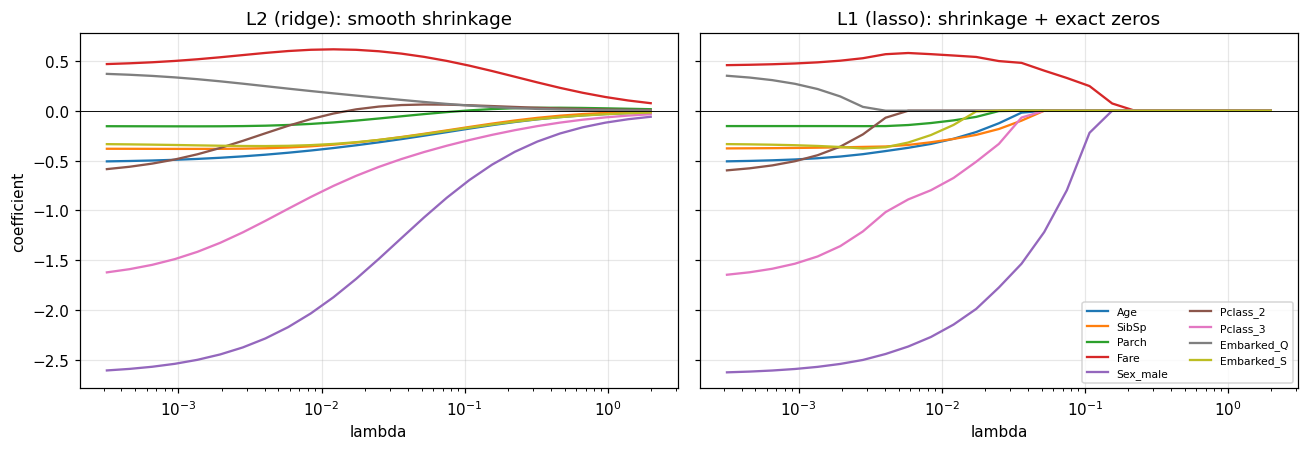

In [8]:
path_lams = np.logspace(-3.5, 0.3, 25)
paths = {pen: np.array([LogisticRegressionScratch(pen, l, max_iter=5000, tol=1e-8).fit(X_train, y_train).coef_ for l in path_lams]) for pen in ("l2", "l1")}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, pen, title in zip(axes, ("l2", "l1"), ("L2 (ridge): smooth shrinkage", "L1 (lasso): shrinkage + exact zeros")):
    for j, name in enumerate(feature_names): ax.plot(path_lams, paths[pen][:, j], label=name)
    ax.set_xscale("log"); ax.set_xlabel("lambda"); ax.set_title(title); ax.axhline(0, c="k", lw=0.6)
axes[0].set_ylabel("coefficient"); axes[1].legend(fontsize=7, ncol=2)
print("L1: number of exactly-zero coefficients along the path (lambda -> zeros):")
print({round(float(l), 4): int(np.sum(c == 0)) for l, c in list(zip(path_lams, paths["l1"]))[::4]})
plt.tight_layout(); plt.savefig("figs/B_regularisation_path.png", bbox_inches="tight"); plt.show()

## 5. Decision stump & decision tree (building blocks for the ensembles)

* **`DecisionStumpScratch`** – a depth-1 tree chosen to **minimise the weighted misclassification error** (what AdaBoost needs). For every feature, values are sorted once and cumulative weighted class sums give the error of *every* candidate threshold in a single vectorised pass, $O(p\,n\log n)$.
* **`DecisionTreeScratch`** – a CART classifier with Gini impurity $G=2p(1-p)$ and a configurable depth ("levels"), using the same sort-and-cumsum trick. Leaves store the class-1 probability.

In [9]:
class DecisionStumpScratch:
    """One-split tree minimising weighted 0/1 error. Predicts labels in {0, 1}."""
    def fit(self, X, y, sample_weight=None):
        n, p = X.shape
        w = np.full(n, 1.0 / n) if sample_weight is None else sample_weight / sample_weight.sum()
        best = (np.inf, 0, 0.0, 0, 1)                      # (error, feature, threshold, left_label, right_label)
        for j in range(p):
            order = np.argsort(X[:, j], kind="mergesort")
            xs, ys, ws = X[order, j], y[order], w[order]
            cw, cp = np.cumsum(ws), np.cumsum(ws * ys)      # cumulative total weight / positive weight
            valid = xs[1:] != xs[:-1]                        # only split between distinct values
            if not valid.any(): continue
            wl, pl = cw[:-1], cp[:-1]; wr, pr = cw[-1] - wl, cp[-1] - pl
            err_l, err_r = np.minimum(pl, wl - pl), np.minimum(pr, wr - pr)   # each side predicts its weighted majority
            err = np.where(valid, err_l + err_r, np.inf)
            k = int(np.argmin(err))
            if err[k] < best[0]:
                best = (err[k], j, (xs[k] + xs[k + 1]) / 2.0, int(pl[k] > wl[k] - pl[k]), int(pr[k] > wr[k] - pr[k]))
        _, self.feature_, self.threshold_, self.left_label_, self.right_label_ = best
        return self

    def predict(self, X):
        return np.where(X[:, self.feature_] <= self.threshold_, self.left_label_, self.right_label_)


class DecisionTreeScratch:
    """CART classification tree (Gini). max_depth = number of 'levels'."""
    def __init__(self, max_depth=3, min_samples_leaf=1, max_features=None, random_state=None):
        self.max_depth, self.min_samples_leaf, self.max_features, self.random_state = max_depth, min_samples_leaf, max_features, random_state

    def fit(self, X, y, sample_weight=None):
        self._rng = np.random.default_rng(self.random_state)
        w = np.ones(len(y)) if sample_weight is None else np.asarray(sample_weight, float)
        self.n_features_ = X.shape[1]
        self.tree_ = self._grow(X, y.astype(float), w, 0)
        return self

    def _best_split(self, X, y, w):
        n, p = X.shape; W = w.sum()
        feats = np.arange(p) if self.max_features is None else self._rng.choice(p, size=min(self.max_features, p), replace=False)
        best = (np.inf, None, None); idx = np.arange(1, n)
        for j in feats:
            order = np.argsort(X[:, j], kind="mergesort")
            xs, ys, ws = X[order, j], y[order], w[order]
            cw, cp = np.cumsum(ws), np.cumsum(ws * ys)
            valid = (xs[1:] != xs[:-1]) & (idx >= self.min_samples_leaf) & (n - idx >= self.min_samples_leaf)
            if not valid.any(): continue
            wl, pl = cw[:-1], cp[:-1] / cw[:-1]; wr, pr = W - cw[:-1], (cp[-1] - cp[:-1]) / (W - cw[:-1] + 1e-300)
            imp = wl * 2 * pl * (1 - pl) + wr * 2 * pr * (1 - pr)      # weighted Gini of the two children
            imp = np.where(valid, imp, np.inf)
            k = int(np.argmin(imp))
            if imp[k] < best[0]: best = (imp[k], j, (xs[k] + xs[k + 1]) / 2.0)
        return best

    def _grow(self, X, y, w, depth):
        p_leaf = float(np.sum(w * y) / np.sum(w))
        if depth >= self.max_depth or p_leaf in (0.0, 1.0) or len(y) < 2 * self.min_samples_leaf:
            return p_leaf
        imp, j, thr = self._best_split(X, y, w)
        parent_imp = np.sum(w) * 2 * p_leaf * (1 - p_leaf)
        if j is None or imp >= parent_imp - 1e-12: return p_leaf
        mask = X[:, j] <= thr
        return (j, thr, self._grow(X[mask], y[mask], w[mask], depth + 1), self._grow(X[~mask], y[~mask], w[~mask], depth + 1))

    def _predict_one(self, node, x):
        while isinstance(node, tuple):
            node = node[2] if x[node[0]] <= node[1] else node[3]
        return node

    def predict_proba(self, X):
        return np.array([self._predict_one(self.tree_, x) for x in X])

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

# quick sanity: a depth-1 tree and a stump should agree on the split they find for an easy problem
s = DecisionStumpScratch().fit(X_train, y_train)
print("stump splits on:", feature_names[s.feature_], "<=", round(s.threshold_, 3))
print("depth-4 tree train accuracy:", np.mean(DecisionTreeScratch(4).fit(X_train, y_train).predict(X_train) == y_train).round(4))

stump splits on: Sex_male <= 0.5
depth-4 tree train accuracy: 0.8441


## 6. Simple Bagging (configurable estimators and levels)

$$\hat p(x)=\frac1B\sum_{b=1}^{B}\hat p_b(x),\qquad \hat p_b \text{ trained on a bootstrap sample of the training rows.}$$

* **Configurable:** `n_estimators` (B), `max_samples` (bootstrap size), and any base learner through a factory function — tree **depth = "levels"**.
* **Out-of-bag (OOB) estimate:** each row is scored only by trees that did *not* see it, giving a free, honest accuracy estimate used here to choose depth and B without touching the test set.

OOB accuracy vs depth: {1: 0.7893, 2: 0.7528, 3: 0.8174, 4: 0.8272, 5: 0.8287, 6: 0.8371, 8: 0.8385, 10: 0.8272}
OOB accuracy vs #trees (depth=8): {10: 0.817, 25: 0.8329, 50: 0.8427, 100: 0.8385, 200: 0.8441}
selected: depth=8, n_estimators=200   (12.4s)


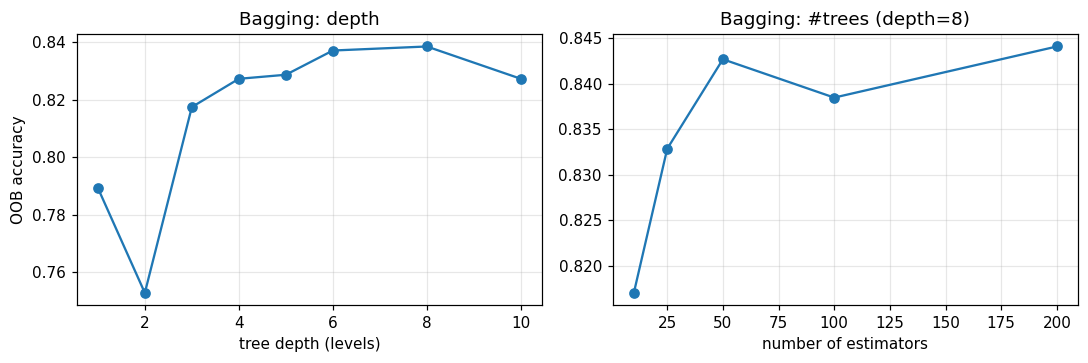

In [10]:
class BaggingScratch:
    def __init__(self, base_factory=lambda: DecisionTreeScratch(max_depth=4), n_estimators=50, max_samples=1.0, random_state=SEED):
        self.base_factory, self.n_estimators, self.max_samples, self.random_state = base_factory, n_estimators, max_samples, random_state

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        n = len(y); m = int(self.max_samples * n)
        self.estimators_, oob_sum, oob_cnt = [], np.zeros(n), np.zeros(n)
        for _ in range(self.n_estimators):
            idx = rng.integers(0, n, size=m)                       # bootstrap sample (with replacement)
            est = self.base_factory().fit(X[idx], y[idx]); self.estimators_.append(est)
            oob = np.setdiff1d(np.arange(n), idx)                  # rows this tree never saw
            if len(oob): oob_sum[oob] += est.predict_proba(X[oob]); oob_cnt[oob] += 1
        seen = oob_cnt > 0
        self.oob_proba_ = np.where(seen, oob_sum / np.maximum(oob_cnt, 1), np.nan)
        self.oob_score_ = float(np.mean((self.oob_proba_[seen] >= 0.5) == y[seen]))
        return self

    def predict_proba(self, X):
        return np.mean([e.predict_proba(X) for e in self.estimators_], axis=0)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

# --- configure "levels" (tree depth) and number of estimators using the OOB score (train data only) ---
t0 = time.perf_counter()
depths, n_ests = [1, 2, 3, 4, 5, 6, 8, 10], [10, 25, 50, 100, 200]
oob_by_depth = [BaggingScratch(lambda d=d: DecisionTreeScratch(max_depth=d), n_estimators=100).fit(X_train, y_train).oob_score_ for d in depths]
best_depth = depths[int(np.argmax(oob_by_depth))]
oob_by_n = [BaggingScratch(lambda: DecisionTreeScratch(max_depth=best_depth), n_estimators=n).fit(X_train, y_train).oob_score_ for n in n_ests]
best_n = n_ests[int(np.argmax(oob_by_n))] if max(oob_by_n) - min(oob_by_n) > 0.003 else 100
print("OOB accuracy vs depth:", {d: round(float(v), 4) for d, v in zip(depths, oob_by_depth)})
print("OOB accuracy vs #trees (depth=%d):" % best_depth, {n: round(float(v), 4) for n, v in zip(n_ests, oob_by_n)})
print(f"selected: depth={best_depth}, n_estimators={best_n}   ({time.perf_counter()-t0:.1f}s)")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(depths, oob_by_depth, "o-"); ax[0].set_xlabel("tree depth (levels)"); ax[0].set_ylabel("OOB accuracy"); ax[0].set_title("Bagging: depth")
ax[1].plot(n_ests, oob_by_n, "o-"); ax[1].set_xlabel("number of estimators"); ax[1].set_title(f"Bagging: #trees (depth={best_depth})")
plt.tight_layout(); plt.savefig("figs/B_bagging_config.png", bbox_inches="tight"); plt.show()

## 7. Simple Boosting — AdaBoost (discrete / SAMME for two classes) with decision stumps

With labels $y\in\{-1,+1\}$ and sample weights $w_i=1/n$ initially, for $t=1..T$:

1. Fit stump $h_t$ minimising the weighted error $\varepsilon_t=\sum_i w_i\,\mathbb 1[h_t(x_i)\ne y_i]$.
2. Stage weight $\alpha_t=\tfrac12\,\eta\,\ln\frac{1-\varepsilon_t}{\varepsilon_t}$ ($\eta$ = learning rate).
3. Re-weight $w_i\leftarrow w_i\,e^{-\alpha_t y_i h_t(x_i)}$ and normalise — misclassified rows gain weight.

Final score $F(x)=\sum_t\alpha_t h_t(x)$; probabilities use the standard additive-logistic link $\hat p(y{=}1|x)=\sigma(2F(x))$ (Friedman, Hastie & Tibshirani, 2000).

In [11]:
class AdaBoostScratch:
    def __init__(self, n_estimators=50, learning_rate=1.0):
        self.n_estimators, self.learning_rate = n_estimators, learning_rate

    def fit(self, X, y):
        n = len(y); ypm = 2 * y - 1                                   # {0,1} -> {-1,+1}
        w = np.full(n, 1.0 / n)
        self.stumps_, self.alphas_ = [], []
        for t in range(self.n_estimators):
            stump = DecisionStumpScratch().fit(X, y, sample_weight=w)
            h = 2 * stump.predict(X) - 1
            err = np.sum(w * (h != ypm)) / np.sum(w)
            if err >= 0.5: break                                       # no better than chance -> stop
            err = max(err, 1e-10)
            alpha = 0.5 * self.learning_rate * np.log((1 - err) / err)
            w = w * np.exp(-alpha * ypm * h); w /= w.sum()             # up-weight mistakes
            self.stumps_.append(stump); self.alphas_.append(alpha)
            if err <= 1e-10: break                                     # perfect stump
        return self

    def decision_function(self, X):
        return sum(a * (2 * s.predict(X) - 1) for a, s in zip(self.alphas_, self.stumps_))

    def predict_proba(self, X):
        return sigmoid(2.0 * self.decision_function(X))                # P(y = 1)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

ada_grid = [(T, lr) for T in (25, 50, 100, 200) for lr in (0.1, 0.5, 1.0)]
t0 = time.perf_counter()
ada_cv = [cv_score(lambda T=T, lr=lr: AdaBoostScratch(T, lr), X_train, y_train) for T, lr in ada_grid]
best_ada = ada_grid[int(np.argmax([m for m, s in ada_cv]))]
for (T, lr), (m, s) in zip(ada_grid, ada_cv): print(f"T={T:3d}  lr={lr:3.1f}  CV-AUC={m:.4f} ± {s:.4f}")
print("selected (n_estimators, learning_rate):", best_ada, f"  ({time.perf_counter()-t0:.1f}s)")

T= 25  lr=0.1  CV-AUC=0.8344 ± 0.0521
T= 25  lr=0.5  CV-AUC=0.8497 ± 0.0478
T= 25  lr=1.0  CV-AUC=0.8552 ± 0.0392
T= 50  lr=0.1  CV-AUC=0.8395 ± 0.0515
T= 50  lr=0.5  CV-AUC=0.8571 ± 0.0431
T= 50  lr=1.0  CV-AUC=0.8612 ± 0.0328
T=100  lr=0.1  CV-AUC=0.8455 ± 0.0482
T=100  lr=0.5  CV-AUC=0.8632 ± 0.0368
T=100  lr=1.0  CV-AUC=0.8690 ± 0.0283
T=200  lr=0.1  CV-AUC=0.8537 ± 0.0440
T=200  lr=0.5  CV-AUC=0.8650 ± 0.0337
T=200  lr=1.0  CV-AUC=0.8732 ± 0.0284
selected (n_estimators, learning_rate): (200, 1.0)   (2.6s)


## 8. Final training and test-set evaluation (all models, identical split, threshold = 0.5)

In [12]:
final_models = {
    "LogReg (none)":   lambda: LogisticRegressionScratch(None),
    "LogReg (L1)":     lambda: LogisticRegressionScratch("l1", best_lam["l1"]),
    "LogReg (L2)":     lambda: LogisticRegressionScratch("l2", best_lam["l2"]),
    "Bagging (trees)": lambda: BaggingScratch(lambda: DecisionTreeScratch(max_depth=best_depth), n_estimators=best_n),
    "AdaBoost (stumps)": lambda: AdaBoostScratch(*best_ada),
}
fitted, probs, preds, results, fit_times = {}, {}, {}, {}, {}
for name, make in final_models.items():
    t0 = time.perf_counter(); m = make().fit(X_train, y_train); fit_times[name] = time.perf_counter() - t0
    fitted[name] = m; probs[name] = m.predict_proba(X_test); preds[name] = m.predict(X_test)      # threshold = 0.5
    results[name] = classification_metrics(y_test, preds[name], probs[name])

cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "avg_precision", "mcc", "balanced_accuracy", "log_loss"]
print(f"{'model':<19}" + "".join(f"{c[:11]:>12}" for c in cols) + f"{'fit (s)':>10}")
for name, r in results.items():
    print(f"{name:<19}" + "".join(f"{r[c]:12.4f}" for c in cols) + f"{fit_times[name]:10.2f}")

model                  accuracy   precision      recall          f1     roc_auc avg_precisi         mcc balanced_ac    log_loss   fit (s)
LogReg (none)            0.7989      0.7797      0.6667      0.7188      0.8379      0.7882      0.5679      0.7742      0.4670      0.06
LogReg (L1)              0.8156      0.8103      0.6812      0.7402      0.8436      0.7948      0.6044      0.7906      0.4642      0.07
LogReg (L2)              0.8212      0.8364      0.6667      0.7419      0.8378      0.7973      0.6170      0.7924      0.4759      0.03
Bagging (trees)          0.8156      0.8103      0.6812      0.7402      0.8457      0.8260      0.6044      0.7906      0.4596      3.17
AdaBoost (stumps)        0.7989      0.7705      0.6812      0.7231      0.7949      0.7636      0.5688      0.7769      0.5481      0.10


### 8.1 Confusion matrices

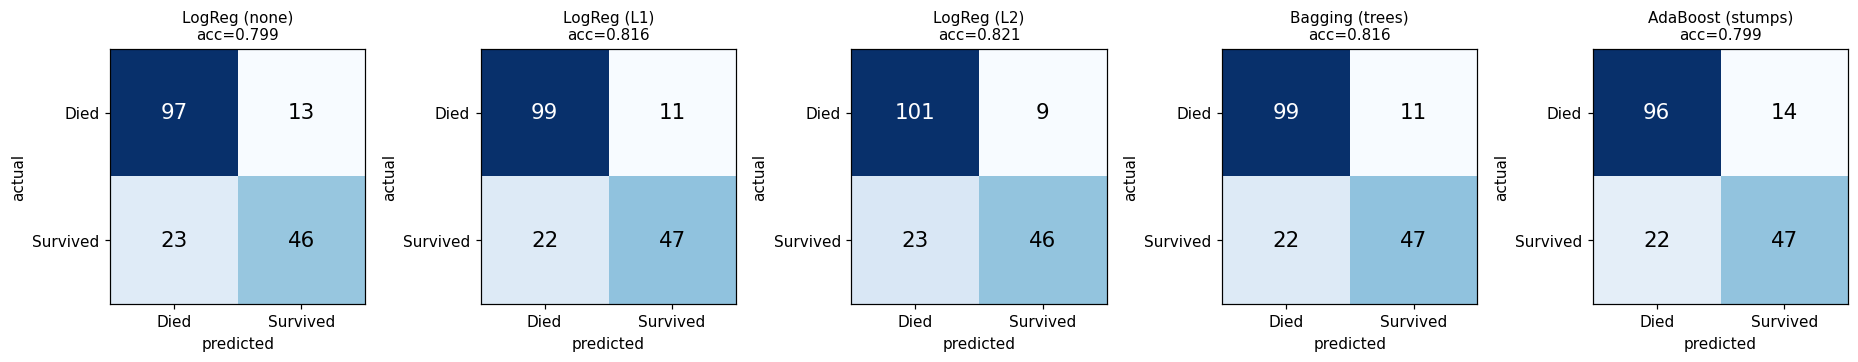

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(17, 3.6))
for ax, (name, yp) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, yp)
    ax.imshow(cm, cmap="Blues"); ax.grid(False)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14, color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks([0, 1], ["Died", "Survived"]); ax.set_yticks([0, 1], ["Died", "Survived"])
    ax.set_xlabel("predicted"); ax.set_ylabel("actual"); ax.set_title(f"{name}\nacc={results[name]['accuracy']:.3f}", fontsize=10)
plt.tight_layout(); plt.savefig("figs/B_confusion_matrices.png", bbox_inches="tight"); plt.show()

### 8.2 ROC and Precision–Recall curves

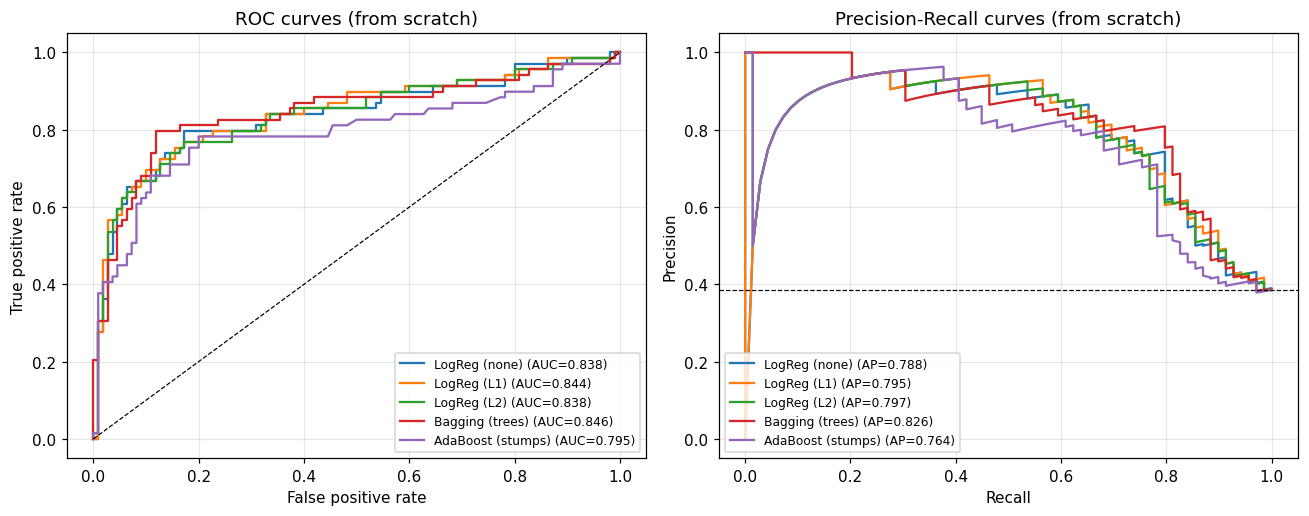

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
for name, p in probs.items():
    fpr, tpr = roc_curve(y_test, p); ax[0].plot(fpr, tpr, label=f"{name} (AUC={results[name]['roc_auc']:.3f})")
    pr, rc = pr_curve(y_test, p);    ax[1].plot(rc, pr, label=f"{name} (AP={results[name]['avg_precision']:.3f})")
ax[0].plot([0, 1], [0, 1], "k--", lw=0.8); ax[0].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC curves (from scratch)")
ax[1].axhline(y_test.mean(), c="k", ls="--", lw=0.8); ax[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall curves (from scratch)")
ax[0].legend(fontsize=8, loc="lower right"); ax[1].legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.savefig("figs/B_roc_pr_curves.png", bbox_inches="tight"); plt.show()

### 8.3 Coefficients: what the logistic models learned (and what L1 removed)

feature          none       L2       L1
Age            -0.518   -0.388   -0.431
SibSp          -0.381   -0.350   -0.362
Parch          -0.154   -0.126   -0.155
Fare            0.449    0.615    0.532
Sex_male       -2.643   -1.960   -2.493
Pclass_2       -0.645   -0.056   -0.212
Pclass_3       -1.702   -0.812   -1.180
Embarked_Q      0.392    0.186    0.016
Embarked_S     -0.329   -0.340   -0.382

L1 exact zeros: 0 | L2 zeros: 0 | ||w||_2  none=3.347  L2=2.307  L1=2.902


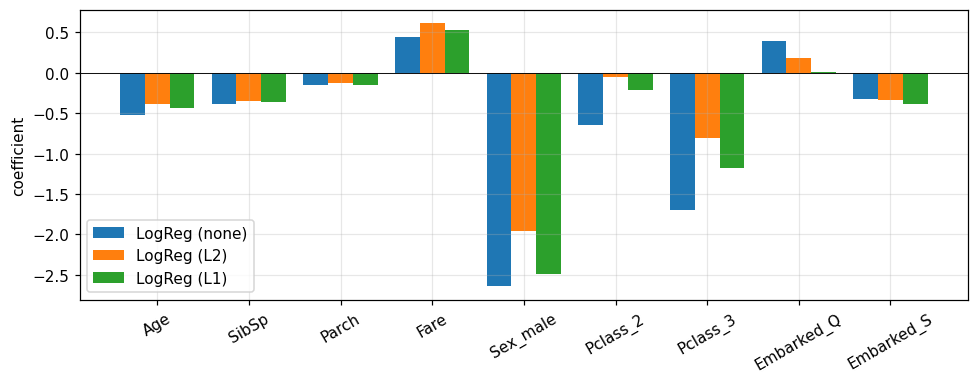

In [15]:
print(f"{'feature':<12}{'none':>9}{'L2':>9}{'L1':>9}")
for j, f in enumerate(feature_names):
    print(f"{f:<12}{fitted['LogReg (none)'].coef_[j]:9.3f}{fitted['LogReg (L2)'].coef_[j]:9.3f}{fitted['LogReg (L1)'].coef_[j]:9.3f}")
print("\nL1 exact zeros:", int(np.sum(fitted['LogReg (L1)'].coef_ == 0)), "| L2 zeros:", int(np.sum(fitted['LogReg (L2)'].coef_ == 0)),
      "| ||w||_2  none=%.3f  L2=%.3f  L1=%.3f" % tuple(np.linalg.norm(fitted[k].coef_) for k in ("LogReg (none)", "LogReg (L2)", "LogReg (L1)")))

fig, ax = plt.subplots(figsize=(9, 3.6)); xpos = np.arange(len(feature_names)); wd = 0.27
for k, (name, off) in enumerate(zip(("LogReg (none)", "LogReg (L2)", "LogReg (L1)"), (-wd, 0, wd))):
    ax.bar(xpos + off, fitted[name].coef_, wd, label=name)
ax.set_xticks(xpos, feature_names, rotation=30); ax.axhline(0, c="k", lw=0.6); ax.set_ylabel("coefficient"); ax.legend()
plt.tight_layout(); plt.savefig("figs/B_coefficients.png", bbox_inches="tight"); plt.show()

### 8.4 The `threshold` argument of `predict` — trading precision for recall

In [16]:
m = fitted["LogReg (L2)"]
print(f"{'threshold':>9}{'precision':>11}{'recall':>9}{'f1':>8}{'accuracy':>10}")
for th in (0.3, 0.4, 0.5, 0.6, 0.7):
    r = classification_metrics(y_test, m.predict(X_test, threshold=th), m.predict_proba(X_test))
    print(f"{th:9.1f}{r['precision']:11.3f}{r['recall']:9.3f}{r['f1']:8.3f}{r['accuracy']:10.3f}")

threshold  precision   recall      f1  accuracy
      0.3      0.618    0.797   0.696     0.732
      0.4      0.732    0.754   0.743     0.799
      0.5      0.836    0.667   0.742     0.821
      0.6      0.902    0.536   0.673     0.799
      0.7      0.923    0.348   0.505     0.737


## 9. Performance notes & save results for Section C

In [17]:
total = time.perf_counter() - NB_START
print(f"Total wall-clock time of this notebook: {total:.1f} s  (limit: 300 s on CPU)")
print("""
Performance considerations
 * Stump / tree split search is vectorised: each feature is sorted once and cumulative weighted sums score every
   threshold at once (O(p n log n) per node instead of O(p n^2)).
 * Logistic regression uses the exact Lipschitz step size 1/L, so no learning-rate tuning is needed and the objective
   decreases monotonically; L1 uses a proximal step, giving exact zeros without sub-gradient oscillation.
 * Bagging OOB scores replace nested cross-validation for tuning depth / #trees.
""")

n_train = len(y_train)
out = {
    "seed": SEED, "n_train": int(n_train), "n_test": int(len(y_test)), "feature_names": feature_names,
    "selected_hyperparameters": {"lambda_l1": best_lam["l1"], "lambda_l2": best_lam["l2"], "bagging_depth": best_depth,
                                 "bagging_n_estimators": best_n, "adaboost_n_estimators": best_ada[0], "adaboost_learning_rate": best_ada[1]},
    "metrics": results, "fit_time_s": fit_times,
    "coefficients": {k: fitted[k].coef_.tolist() for k in ("LogReg (none)", "LogReg (L1)", "LogReg (L2)")},
    "intercepts": {k: float(fitted[k].intercept_) for k in ("LogReg (none)", "LogReg (L1)", "LogReg (L2)")},
    "test_probabilities": {k: v.tolist() for k, v in probs.items()},
    "notebook_runtime_s": total,
}
with open("data/results/results_B.json", "w") as fh: json.dump(out, fh)
print("saved data/results/results_B.json")

Total wall-clock time of this notebook: 24.1 s  (limit: 300 s on CPU)

Performance considerations
 * Stump / tree split search is vectorised: each feature is sorted once and cumulative weighted sums score every
   threshold at once (O(p n log n) per node instead of O(p n^2)).
 * Logistic regression uses the exact Lipschitz step size 1/L, so no learning-rate tuning is needed and the objective
   decreases monotonically; L1 uses a proximal step, giving exact zeros without sub-gradient oscillation.
 * Bagging OOB scores replace nested cross-validation for tuning depth / #trees.

saved data/results/results_B.json
